In [1]:
# Provides ways to work with large multidimensional arrays
import numpy as np 
# Allows for further data manipulation and analysis
import pandas as pd
# from pandas_datareader import data as web # Reads stock data 
import matplotlib.pyplot as plt # Plotting
import matplotlib.dates as mdates # Styling dates
%matplotlib inline

import time
import datetime as dt # For defining dates
from datetime import timezone
# import mplfinance as mpf # Matplotlib finance
import os
from os import listdir
from os.path import isfile, join
from pathlib import Path

import requests
import json
import csv

In [791]:
# Define path to files
PATH = "/Users/hialfonso/Banas/Section53_Finance/"
PATH = "C:/Udemy/2026-Python-EricBanas/Banas/Section53_Finance/redo/"

# Start date defaults
S_YEAR = 2017
S_MONTH = 1
S_DAY = 3
S_DATE_STR = "2017-01-03"
S_DATE_DATETIME = dt.datetime(S_YEAR, S_MONTH, S_DAY)

# End date defaults
E_YEAR = 2021
E_MONTH = 8
E_DAY = 19
E_DATE_STR = "2026-09-01"
E_DATE_DATETIME = dt.datetime(E_YEAR, E_MONTH, E_DAY)

missing_tickers = []
tickers_to_skip = ['FIT']
risk_free_rate = 0.0125 # Approximate 10 year bond rate

SDATE = '2025-01-01'
EDATE = '2026-01-31'


In [792]:
def get_df_from_csv(ticker):
    
    # Try to get the file and if it doesn't exist issue a warning
    try:

        if ticker not in tickers_to_skip:
            df = pd.read_csv(PATH + 'converted/' + ticker + '.csv')
            # df['date2'] = pd.DatetimeIndex(['date'])
            df = df.set_index(pd.to_datetime(df['date']))
            df.drop(columns=['date'], inplace=True)
            df = df.loc[S_DATE_STR:E_DATE_STR]
            return df
        else:
            return None
        # df = delete_unnamed_cols(df)
        
    except FileNotFoundError:
        missing_tickers.append(ticker)
        print(f"File for ticker {ticker} doesn't exist")
        return None
        
def merge_df_by_column_name(col_name, sdate, edate, *tickers):

    mult_df = pd.DataFrame()
    for x in tickers:
        df = get_df_from_csv(x)
        if df is not None:
            mask = (df.index >= sdate) & (df.index <= edate)
            mult_df[x] = df.loc[mask][col_name]
        else:
            print (x + " not found")

    return mult_df
    
def get_valid_dates(df, sdate, edate):
    
    try:
        # mask = (df['date'] > sdate) & (df['date'] <= edate) 
        sm_df = df.loc[sdate:edate]
        if not sm_df.empty:
            sm_date = str(sm_df.index.min()).split(' ')[0]
            last_date = str(sm_df.index.max()).split(' ')[0]
            
            date_leading = str(sm_df.index.min()).split(' ')[0] #'-'.join(('0' if len(x) < 2 else '')+x for x in sm_date.split('-'))
            date_ending = str(sm_df.index.max()).split(' ')[0]  #'-'.join(('0' if len(x) < 2 else '')+x for x in last_date.split('-'))
            # print(date_leading, " ", date_ending)
        else:
            return None, None
    except Exception:
        print("Date Corrupted")
    else:
        return date_leading, date_ending

## Stock Portfolio

In [793]:
# port_list = ["GNRC", "CPRT", "ODFL", 
#             "AMD", "PAYC",
#             "CHTR",
#             "MKC", "PG",
#             "PGR",
#             "NEM",
#             "CCI",
#             "COG"]

port_list = [
     "MSFT",  # Technology
    "NFLX",  # Communication Services
    "HD",    # Consumer Discretionary
    "KO",    # Consumer Staples
    "GS",    # Financials
    "ISRG",  # Healthcare
    "VRT",   # Industrials
    "SLB",   # Energy
    "NEE",   # Utilities
    "EQIX",  # Real Estate
    "SHW"    # Materials
]
num_stocks = len(port_list)
num_stocks

# Calculated Weighting
# Stock : GNRC : 21.90 
# Stock : CPRT : 15.63 
# Stock : ODFL : 23.83
# Stock : AMD : 11.09
# Stock : PAYC : 1.86
# Stock : CHTR : 3.55
# Stock : MKC : 2.87
# Stock : PG : 1.09
# Stock : PGR : 2.86
# Stock : NEM : 10.11
# Stock : CCI : 4.34
# Stock : COG : 0.87

11

## Merge all Stock Price Data

In [794]:
hyp_start_date = SDATE
hyp_end_date = EDATE


mult_df = merge_df_by_column_name('close',  hyp_start_date, 
                                  hyp_end_date, *port_list)
mult_df



,MSFT,NFLX,HD,KO,GS,ISRG,VRT,SLB,NEE,EQIX,SHW
date,,,,,,,,,,,
2025-01-02,414.568596,88.673,376.493727,59.657596,560.520718,524.030,118.105747,37.003393,68.975225,918.057078,329.489805
2025-01-03,419.292884,88.105,377.191548,59.570773,565.551045,535.295,125.463645,37.186483,69.341244,933.360784,332.832570
2025-01-06,423.749758,88.179,377.375695,58.663946,568.729119,542.370,133.859835,37.350300,68.618839,913.944329,334.098469
2025-01-07,418.322275,87.919,372.394030,58.692888,565.541296,531.880,130.425484,37.938114,67.838642,914.012388,330.716145
2025-01-08,420.491288,87.500,375.272541,59.532184,565.443809,544.020,129.057733,37.398481,68.060179,924.678313,333.821554
...,...,...,...,...,...,...,...,...,...,...,...
2026-01-26,469.209041,85.700,383.962977,72.064486,926.981545,528.810,181.187215,49.408635,84.890971,801.978986,347.561462
2026-01-27,479.485585,85.580,377.833953,73.047726,924.852748,525.040,189.165331,50.363007,86.559589,805.161640,345.316426
2026-01-28,480.533194,84.640,372.807558,72.561072,931.905631,522.040,193.714257,48.583501,86.976744,811.725863,348.828660


## Plot Growth of Investments over Total Dataset

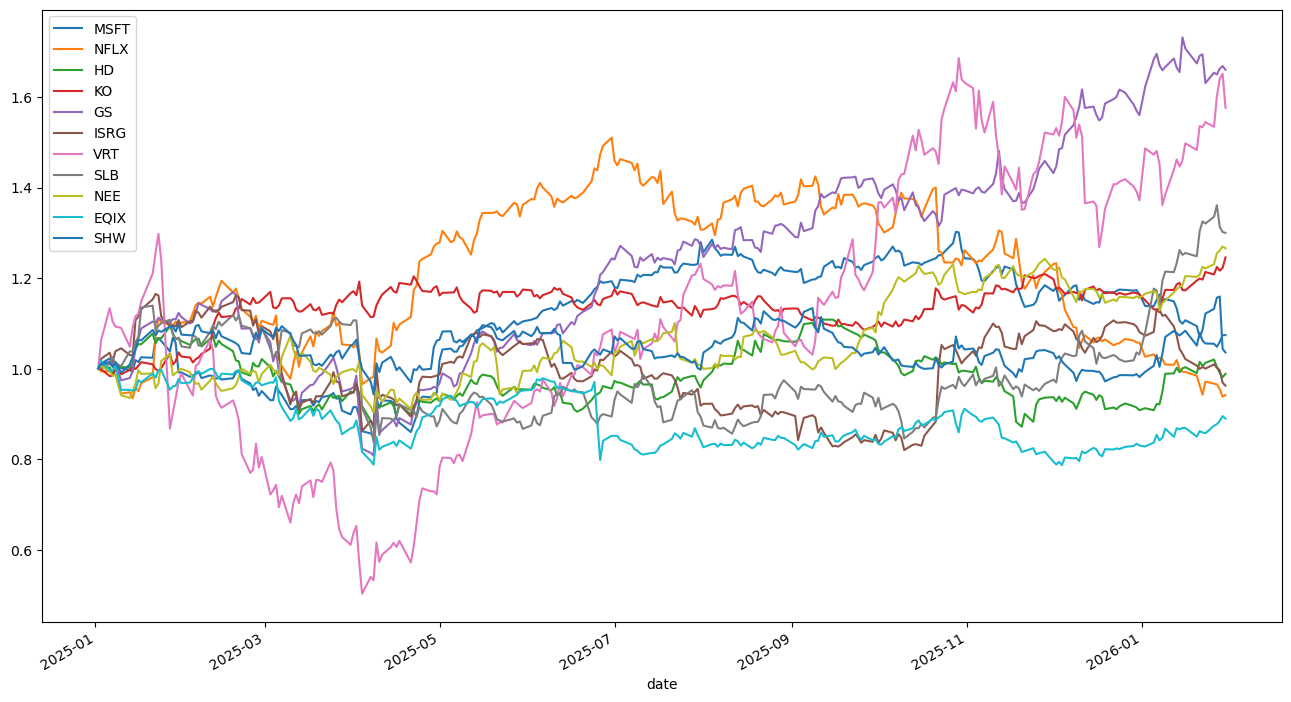

In [797]:
(mult_df / mult_df.iloc[0]).plot(figsize=(16, 9))
plt.show()

## Mean Returns

Many finance models assume returns are approximately normally distributed. Log returns often behave better statistically than raw percent returns.

Used in:

Portfolio theory,
Black-Scholes,
Risk models,
Monte Carlo simulations

np.log() is used because it converts price changes into log returns, which are:

additive through time,
statistically convenient,
standard in quantitative finance,
useful for annualizing returns and volatility

Use log returns when asking:
What is expected return?
Volatility?
Correlations?
Statistical modeling?
Optimization?

In [798]:
returns = np.log(mult_df / mult_df.shift(1))
returns
mean_ret = returns.mean() * 252 # 252 average trading days per year
mean_ret

MSFT    0.032733
NFLX   -0.056422
HD     -0.010991
KO      0.205607
GS      0.474837
ISRG   -0.036101
VRT     0.426149
SLB     0.245627
NEE     0.220762
EQIX   -0.109847
SHW     0.066840
dtype: float64

## Covariance

In [799]:
returns.cov() * 252

,MSFT,NFLX,HD,KO,GS,ISRG,VRT,SLB,NEE,EQIX,SHW
MSFT,0.068199,0.035898,0.012589,-0.005748,0.035559,0.038946,0.080734,0.019900,0.003206,0.016509,0.011927
NFLX,0.035898,0.111788,0.004678,0.004075,0.040470,0.033094,0.072365,0.001775,0.002920,0.025591,0.010599
HD,0.012589,0.004678,0.054216,0.010018,0.030398,0.026842,0.013404,0.032276,0.013995,0.020266,0.040382
KO,-0.005748,0.004075,0.010018,0.030989,-0.002055,0.000897,-0.033131,0.006391,0.018105,0.007293,0.013767
GS,0.035559,0.040470,0.030398,-0.002055,0.097683,0.058969,0.110696,0.055484,0.013501,0.038455,0.033606
ISRG,0.038946,0.033094,0.026842,0.000897,0.058969,0.123150,0.101057,0.046856,0.007994,0.039453,0.029215
VRT,0.080734,0.072365,0.013404,-0.033131,0.110696,0.101057,0.501408,0.065865,0.007405,0.073276,0.027777
SLB,0.019900,0.001775,0.032276,0.006391,0.055484,0.046856,0.065865,0.140107,0.026543,0.025449,0.030198
NEE,0.003206,0.002920,0.013995,0.018105,0.013501,0.007994,0.007405,0.026543,0.075304,0.015881,0.016250
EQIX,0.016509,0.025591,0.020266,0.007293,0.038455,0.039453,0.073276,0.025449,0.015881,0.074271,0.024930


## Correlation

In [801]:
returns.corr()

,MSFT,NFLX,HD,KO,GS,ISRG,VRT,SLB,NEE,EQIX,SHW
MSFT,1.000000,0.411138,0.207035,-0.125034,0.435663,0.424972,0.436588,0.203578,0.044743,0.231968,0.187878
NFLX,0.411138,1.000000,0.060091,0.069239,0.387283,0.282058,0.305659,0.014182,0.031828,0.280851,0.130412
HD,0.207035,0.060091,1.000000,0.244399,0.417704,0.328497,0.081299,0.370333,0.219034,0.319363,0.713465
KO,-0.125034,0.069239,0.244399,1.000000,-0.037357,0.014513,-0.265787,0.096997,0.374789,0.152010,0.321731
GS,0.435663,0.387283,0.417704,-0.037357,1.000000,0.537651,0.500180,0.474278,0.157412,0.451473,0.442336
ISRG,0.424972,0.282058,0.328497,0.014513,0.537651,1.000000,0.406678,0.356710,0.083012,0.412530,0.342476
VRT,0.436588,0.305659,0.081299,-0.265787,0.500180,0.406678,1.000000,0.248502,0.038108,0.379711,0.161376
SLB,0.203578,0.014182,0.370333,0.096997,0.474278,0.356710,0.248502,1.000000,0.258406,0.249476,0.331887
NEE,0.044743,0.031828,0.219034,0.374789,0.157412,0.083012,0.038108,0.258406,1.000000,0.212350,0.243605
EQIX,0.231968,0.280851,0.319363,0.152010,0.451473,0.412530,0.379711,0.249476,0.212350,1.000000,0.376313


## Generate Random Weights Equal to 1

In [686]:
weights = np.random.random(len(mult_df.columns))
weights /= np.sum(weights)
print('Weights: ', weights)
print('Total Weight: ', np.sum(weights))


Weights:  [0.10810376 0.09620726 0.07369832 0.02582793 0.11445039 0.13074733
 0.1045177  0.13679666 0.0303517  0.1076265  0.07167246]
Total Weight:  1.0


## Calculating Return of Portfolio

In [802]:
np.sum(weights * returns.mean()) * 252

np.float64(0.13004565021593897)

## Calculating Volatility (Risk)

In [803]:
np.sqrt(np.dot(weights.T, np.dot(returns.cov() * 252, weights)))

# port_var = np.dot(wts.T, np.dot(mult_df.cov() * 756, wts))
# np.dot(weights.T, np.dot(df.cov() * days, weights))


np.float64(0.2179532134010637)

## Analyzing Returns & Risks of 10000 Combinations

In [804]:
p_ret = []
p_vol = []
p_SR = []
p_wt = []

for x in range(10000):
    p_weights = np.random.random(len(mult_df.columns))
    p_weights /= np.sum(p_weights)

    ret_1 = np.sum(p_weights * returns.mean()) * 252
    p_ret.append(ret_1)

    vol_1 = np.sqrt(np.dot(p_weights.T, np.dot(returns.cov() * 252, p_weights)))
    p_vol.append(vol_1)

    SR_1 = (ret_1 - risk_free_rate) / vol_1
    p_SR.append(SR_1)

    p_wt.append(p_weights)

p_ret = np.array(p_ret)
p_vol = np.array(p_vol)
p_SR = np.array(p_SR)
p_wt = np.array(p_wt)


In [249]:
# p_ret, p_vol, p_SR, p_wt

## Plotting the Efficient Frontier

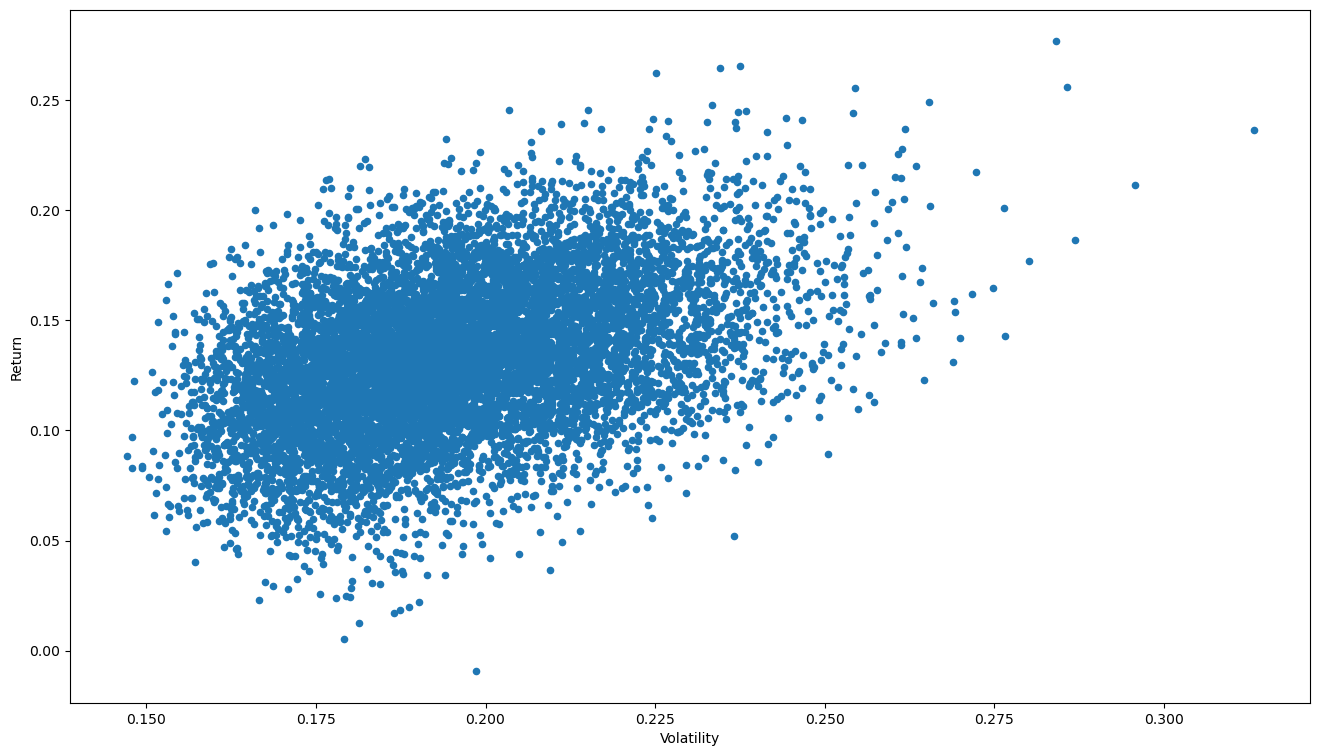

In [805]:
# Create a dataframe with returns and volatility
ports = pd.DataFrame({'Return': p_ret, 'Volatility': p_vol})
ports.plot(x='Volatility', y='Return', kind='scatter', figsize=(16, 9))
plt.show()

## Sharpe Ratio

*People want to maximize returns while avoiding as much risk as possible. William Sharpe created the Sharpe Ratio to find the portfolio that provides the best return for the lowest amount of risk.

Sharpe Ratio = \frac{r_i - r_f}{\sigma_i}
 
 Risk Free Rate = r_f

 Rate of Return of the stock = r_i

 Standard Deviation of the Stock = sigma_i

As return increases so does the Sharpe Ratio, but as Standard Deviation increase the Sharpe Ration decreases.*

In [775]:
# Return the index of the largest Sharpe Ratio
SR_idx = np.argmax(p_SR)

print ("Max Sharpe Ratio: ", p_wt[SR_idx])

# Find the ideal portfolio weighting at that index
i = 0
while i < num_stocks:
    print("Stock : %s : %2.2f" % (port_list[i], (p_wt[SR_idx][i] * 100)))
    i += 1

# Find volatility of that portfolio
print("\nVolatility :", p_vol[SR_idx])
      
# Find return of that portfolio
print("Return :", p_ret[SR_idx])

# Best weights
print("Best Weights: \n", pd.Series(p_wt[SR_idx]))

pd.DataFrame({'weight': p_wt[SR_idx] * 100, 'mean_return': mean_ret}).sort_values(by="weight", ascending=False)

Max Sharpe Ratio:  [0.01540338 0.20257635 0.00863226 0.22170989 0.17936663 0.03502711
 0.13179128 0.04963861 0.10549081 0.03033687 0.0200268 ]
Stock : MSFT : 1.54
Stock : NFLX : 20.26
Stock : HD : 0.86
Stock : KO : 22.17
Stock : GS : 17.94
Stock : ISRG : 3.50
Stock : VRT : 13.18
Stock : SLB : 4.96
Stock : NEE : 10.55
Stock : EQIX : 3.03
Stock : SHW : 2.00

Volatility : 0.1778128450937858
Return : 0.30001510482385607
Best Weights: 
 0     0.015403
1     0.202576
2     0.008632
3     0.221710
4     0.179367
5     0.035027
6     0.131791
7     0.049639
8     0.105491
9     0.030337
10    0.020027
dtype: float64


,weight,mean_return
KO,22.170989,0.136368
NFLX,20.257635,0.317892
GS,17.936663,0.386382
VRT,13.179128,0.781040
NEE,10.549081,0.210838
SLB,4.963861,0.004880
ISRG,3.502711,0.164068
EQIX,3.033687,0.121840
SHW,2.002680,0.050419
MSFT,1.540338,0.006168


## Get Number of Shares & Cost Based on Weights

In [723]:
def get_port_shares(one_price, force_one, wts, prices):
    # Gets number of stocks to analyze
    num_stocks = len(wts)
    
    # Holds the number of shares for each
    shares = []
    
    # Holds Cost of shares for each
    cost_shares = []
    
    i = 0
    while i < num_stocks:
        # Get max amount to spend on stock 
        max_price = one_price * wts[i]
        
        # Gets number of shares to buy and adds them to list
        num_shares = int(max_price / prices[i])
        
        # If the user wants to force buying one share do it
        if(force_one & (num_shares == 0)):
            num_shares = 1
        
        shares.append(num_shares)
        
        # Gets cost of those shares and appends to list
        cost = num_shares * prices[i]
        cost_shares.append(cost)
        i += 1
        
    return shares, cost_shares

## Get Portfolio Weighting

In [724]:
def get_port_weighting(share_cost):
    
    # Holds weights for stocks
    stock_wts = []
    # All values summed
    tot_val = sum(share_cost)
    print("Total Investment :", tot_val)
    
    for x in share_cost:
        stock_wts.append(x / tot_val)
        
    return stock_wts

## Returns the Value of Portfolio by Date

In [786]:
SDATE

NameError: name 'SDATE' is not defined

In [782]:
def get_port_val_by_date(date, shares, tickers):
    
    port_prices = merge_df_by_column_name('close',  date, 
                                  date, *tickers)
    
    # Convert from dataframe to Python list
    port_prices = port_prices.values.tolist()
    # Trick that converts a list of lists into a single list
    port_prices = sum(port_prices, [])
    
    # Create a list of values by multiplying shares by price
    value_list = []
    
    for price, share in zip(port_prices, shares):
        value_list.append(price * share)
    
    return sum(value_list)
    
def round_up(x):
    if round(x) == 0:
        return 1
    else:
        return round(x)

## Approximate Portfolio Weighting Based on Request

## Mine

In [691]:
port_wts = p_wt[SR_idx] * 100
port_wts

array([ 1.54033826, 20.25763503,  0.86322622, 22.17098868, 17.93666348,
        3.50271141, 13.17912778,  4.96386133, 10.54908122,  3.03368703,
        2.00267956])

In [750]:

        
port_wts2 = p_wt[SR_idx] * 100
port_wts2 = pd.Series(port_wts2).apply(lambda x: round_up(x))
port_wts2 = port_wts2.tolist()
port_wts2



[2, 20, 1, 22, 18, 4, 13, 5, 11, 3, 2]

In [529]:
hyp_start_date = '2024-01-02'
hyp_end_date = '2025-12-31'

date = hyp_end_date

port_wts = p_wt[SR_idx]

start_prices = merge_df_by_column_name('close', date,  date, *port_list)

start_prices = start_prices.reset_index()

spend_per_share = port_wts * 10000
spend_per_share = pd.DataFrame(spend_per_share)

spend_per_share = pd.DataFrame(spend_per_share.T)
start_prices = start_prices.drop(columns=['date'])

# Assign directly to df.columns
spend_per_share.columns = np.array(port_list)

shares_df = spend_per_share / start_prices

for index in shares_df.columns:
    shares_df[index] = round_up(float(shares_df[index]))
    
shares_df = (shares_df  * start_prices)
shares_df.sum(axis=1)

C:\Users\admin\AppData\Local\Temp\ipykernel_14288\793524796.py:24: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  shares_df[index] = round_up(float(shares_df[index]))


0    10919.259075
dtype: float64

In [704]:
        
port_wts = p_wt[SR_idx] * 100
port_wts = pd.Series(port_wts).apply(lambda x: round_up(x))
port_wts = port_wts.tolist()
port_wts


[2, 20, 1, 22, 18, 4, 13, 5, 11, 3, 2]

In [728]:
port_list
port_wts = port_wts2
port_wts2

[2, 20, 1, 22, 18, 4, 13, 5, 11, 3, 2]

## Approximate Portfolio Weighting Based on Request

'2026-04-01'

In [783]:
# port_list = ["GNRC", "CPRT", "ODFL", "AMD", "PAYC", "CHTR", "MKC", 
#              "PG", "PGR", "NEM", "CCI", "COG"]



# port_wts = [22, 16, 24, 11, 2, 4, 3, 1, 3, 10, 4, 1]
port_wts = [2, 20, 1, 22, 18, 4, 13, 5, 11, 3, 2]


# Get all stock prices on the starting date
# port_df_start = merge_df_by_column_name('close',  '2020-01-02', 
#                                   '2020-01-02', *port_list)

port_df_start = merge_df_by_column_name('close',  hyp_start_date, 
                                  hyp_start_date, *port_list)

# Convert from dataframe to Python list
port_prices = port_df_start.values.tolist()

# Trick that converts a list of lists into a single list
port_prices = sum(port_prices, [])

# Calculated Weighting
# Stock : GNRC : 21.90 
# Stock : CPRT : 15.63 
# Stock : ODFL : 23.83
# Stock : AMD : 11.09
# Stock : PAYC : 1.86
# Stock : CHTR : 3.55
# Stock : MKC : 2.87
# Stock : PG : 1.09
# Stock : PGR : 2.86
# Stock : NEM : 10.11
# Stock : CCI : 4.34
# Stock : COG : 0.87

tot_shares, share_cost = get_port_shares(100, True, port_wts, port_prices)
# tot_shares, share_cost = get_port_shares(47.03, True, port_wts, port_prices)

print("Shares :", tot_shares)

print("Share Cost:", share_cost)

print("Share Cost Sum:", sum(share_cost))

# Get list of weights for stocks
stock_wts = get_port_weighting(share_cost)

print("Stock Weights :", stock_wts)
print("Stock Weights Sum :", sum(stock_wts))

# Get value at end of year
print ('Start value: ', get_port_val_by_date('2025-01-02', tot_shares, port_list))
print('Enda vlaue: ' , get_port_val_by_date('2025-12-31', tot_shares, port_list))



Shares : [1, 42, 1, 39, 4, 1, 28, 10, 18, 1, 1]
Share Cost: [364.32403539, 1975.092, 320.00211705, 2189.05641123, 1453.57032036, 322.13, 1272.3458552000002, 494.8843144, 1044.35422038, 759.00218241, 291.06155925]
Share Cost Sum: 10485.823015670001
Total Investment : 10485.823015670001
Stock Weights : [0.034744438738433275, 0.18835831932776523, 0.030517596622772404, 0.208763433061828, 0.1386224350904823, 0.03072052613501194, 0.12133962716122598, 0.047195562395097215, 0.09959678117962875, 0.07238365374618169, 0.02775762654157313]
Stock Weights Sum : 0.9999999999999999
Start value:  15774.18323122
Enda vlaue:  18971.40861453


In [ ]:
port_list = top_1

df = get_df_from_csv('MSFT')
sdate, edate = get_valid_dates(df, SDATE, EDATE)

weights = get_best_weights(SDATE, EDATE, *port_list)

port_wts = weights * 100
port_wts = pd.Series(port_wts).apply(lambda x: round_up(x)).tolist()

port_df_start = merge_df_by_column_name('close', sdate,  edate, *port_list)

# Convert from dataframe to Python list
port_prices = port_df_start.values.tolist()

# Trick that converts a list of lists into a single list
port_prices = sum(port_prices, [])

tot_shares, share_cost = get_port_shares(100, True, port_wts, port_prices)

print("Shares To Buy:", tot_shares)
print("Shares Cost :", share_cost)
print("Shares Total Cost :", sum(share_cost))


# Portfolio value at start of 2020
port_val_start = get_port_val_by_date(sdate, tot_shares, port_list)
print("Portfolio Value at Start of 2020 : $%2.2f" % (port_val_start))

# Portfolio value at end of 2020
port_val_end = get_port_val_by_date(edate, tot_shares, port_list)
print("Portfolio Value at End of 2020 : $%2.2f" % (port_val_end))